In [24]:
import os
import json
import yaml
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.stats import spearmanr
import seaborn as sns
from huggingface_hub import login
from datasets import load_dataset, Dataset
from scipy.spatial.distance import jensenshannon
import pingouin as pg
from scipy.stats import pearsonr, pointbiserialr
from huggingface_hub import login

In [2]:
def write_to_json(file, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(file, f, indent=2)


def read_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)

def get_hf_dataset(dataset_path, name= "analysis", split="train"):
    dataset = load_dataset(dataset_path, name=name)
    dataset = dataset[split].to_pandas()
    return dataset


In [3]:
RESPONSE_DATASET_PATH = "thoughtworks/gemma_psychometrics_personas_responses"

PERSONA_SJT_RESPONSE_DATASET_CONFIG = "analysis_sjt"
BASE_SJT_RESPONSE_DATASET_CONFIG = "base_sjt"

PERSONA_EMOBENCH_RESPONSE_DATASET_CONFIG = "analysis_emo_bench"
BASE_EMOBENCH_RESPONSE_DATASET_CONFIG = "base_emo_bench"

PERSONA_ADVBENCH_RESPONSE_DATASET_CONFIG = "analysis_advbench"
BASE_ADVBENCH_RESPONSE_DATASET_CONFIG = "base_advbench"

PERSONA_TRUTHFULQA_RESPONSE_DATASET_CONFIG = "analysis_truthfulqa_mc"
BASE_TRUTHFULQA_RESPONSE_DATASET_CONFIG = "base_truthfulqa_mc"


PERSONA_DATASET_PATH = "thoughtworks/psychometric_personas"
PERSONA_DATASET_CONFIG = "analysis"

In [4]:
# sjt_base_responses = get_hf_dataset(RESPONSE_DATASET_PATH, BASE_SJT_RESPONSE_DATASET_CONFIG)
# sjt_persona_responses = get_hf_dataset(RESPONSE_DATASET_PATH, PERSONA_SJT_RESPONSE_DATASET_CONFIG)

In [4]:
emobench_base_responses = get_hf_dataset(RESPONSE_DATASET_PATH, BASE_EMOBENCH_RESPONSE_DATASET_CONFIG)
emobench_persona_responses = get_hf_dataset(RESPONSE_DATASET_PATH, PERSONA_EMOBENCH_RESPONSE_DATASET_CONFIG)

In [4]:
# truthfulqa_base_responses = get_hf_dataset(RESPONSE_DATASET_PATH, BASE_TRUTHFULQA_RESPONSE_DATASET_CONFIG)
# truthfulqa_persona_responses = get_hf_dataset(RESPONSE_DATASET_PATH, PERSONA_TRUTHFULQA_RESPONSE_DATASET_CONFIG)

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

In [7]:
sjt_persona_dist = pd.crosstab([sjt_persona_responses["persona_uuid"], sjt_persona_responses["question_hash"]], sjt_persona_responses["normalized_answer"]).reset_index()

sjt_base_dist = pd.crosstab([sjt_base_responses["persona_uuid"], sjt_base_responses["question_hash"]], sjt_base_responses["normalized_answer"]).reset_index()

In [5]:
emobench_persona_dist = pd.crosstab([emobench_persona_responses["persona_uuid"], emobench_persona_responses["question_hash"]], emobench_persona_responses["is_correct"]).reset_index()

emobench_base_dist = pd.crosstab([emobench_base_responses["persona_uuid"], emobench_base_responses["question_hash"]], emobench_base_responses["is_correct"]).reset_index()

In [6]:
emobench_persona_dist.columns = ['persona_uuid', 'question_hash', 'False', 'True']
emobench_base_dist.columns = ['persona_uuid', 'question_hash', 'False', 'True']

In [11]:
train_emobench_dist

,persona_uuid,question_hash,False,True,most_frequent
0,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,0018e6c2c7679a095e8e105425612945ce233b51df7da4...,5,0,False
1,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,0214a815a52f6979b3788324c342c2f964cf801f7bfca9...,1,4,True
2,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,03ded2360330622f9e99f3220bd4fafae118db65cc175c...,1,4,True
4,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,0553dc18dd517ed3574de62ec5e44a426783b46af5a4a6...,3,2,False
5,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,05c2354be2510de13a6d470e4cf42bc7581f4b0d71637b...,4,1,False
...,...,...,...,...,...
199994,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,fc2f25c1b102156b79794189a5c18a029677bcaea31bc6...,3,2,False
199995,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,fd0493f536eeefc6b4ba38d4a9fe923941e1823eca1886...,0,5,True
199997,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,fe488f4c61cc42b4177d627e28dbe8aa27955f3ba48b27...,5,0,False
199998,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,ff462206d3a3bd597e2e62509c4b592832fc0065f542ed...,5,0,False


In [8]:
emobench_persona_dist.loc[:,"answer_num"] = emobench_persona_dist.loc[:,"most_frequent"].map({"True": 1, "False": 0})

persona_emobench_accuracy = (
    emobench_persona_dist.groupby("persona_uuid")["answer_num"]
    .mean()
    .reset_index(name="emobench_proportion_correct")
)

In [9]:
persona_emobench_accuracy['emobench_rank'] = persona_emobench_accuracy['emobench_proportion_correct'].rank(method="dense", ascending=False).astype(int)

In [10]:
# persona_emobench_accuracy.to_csv("../../experiment_results/analysis_2026MarARR/persona500_emobench_rank.csv", index = False)

In [11]:
persona_sjt_score = pd.read_csv("../../experiment_results/analysis_2026MarARR/persona500_sjt_score.csv")
persona_emobench_rank = pd.read_csv("../../experiment_results/analysis_2026MarARR/persona500_emobench_rank.csv")
persona_truthfulqa_rank = pd.read_csv("../../experiment_results/analysis_2026MarARR/persona_truthfulqa_rank.csv")

In [12]:
persona_sjt_score = pd.merge(persona_sjt_score, persona_emobench_rank, on = "persona_uuid")
persona_sjt_score = pd.merge(persona_sjt_score, persona_truthfulqa_rank, on = "persona_uuid")

In [17]:
option_cols = ['agreeableness_option',
       'conscientiousness_option', 'emotionality_option',
       'extraversion_option', 'honesty_humility_option', 'openness_option']

for col in option_cols:
    
    rank_col_name = col + "_rank"
    persona_sjt_score[rank_col_name] = persona_sjt_score[col].rank(method="dense", ascending=False).astype(int)

In [18]:
persona_sjt_score.columns

Index(['persona_uuid', 'agreeableness_option', 'conscientiousness_option',
       'emotionality_option', 'extraversion_option', 'honesty_humility_option',
       'openness_option', 'emobench_proportion_correct', 'emobench_rank',
       'truthful_proportion_correct', 'truthfulqa_rank',
       'agreeableness_option_rank', 'conscientiousness_option_rank',
       'emotionality_option_rank', 'extraversion_option_rank',
       'honesty_humility_option_rank', 'openness_option_rank'],
      dtype='object')

In [21]:
rank_cols = ['emobench_rank','truthfulqa_rank',
       'agreeableness_option_rank', 'conscientiousness_option_rank',
       'emotionality_option_rank', 'extraversion_option_rank',
       'honesty_humility_option_rank', 'openness_option_rank']

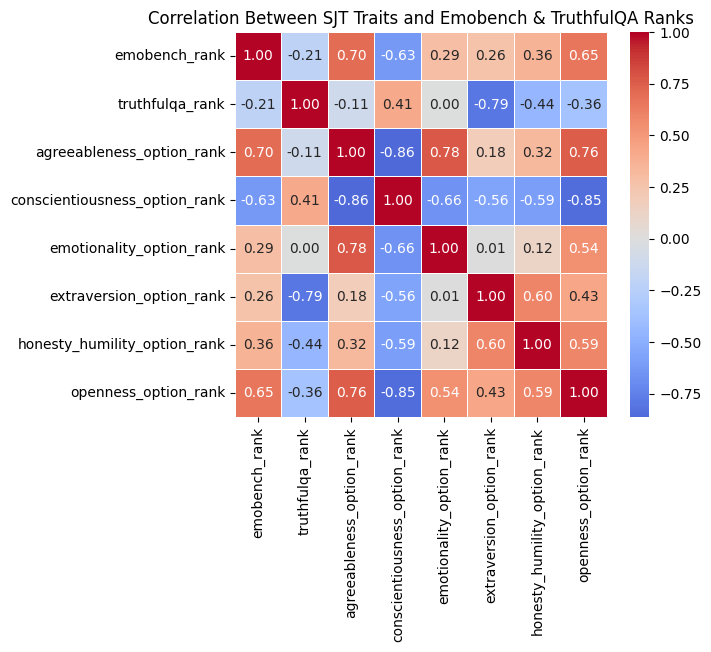

In [25]:
plt.figure(figsize=(6,5))

sns.heatmap(
    persona_sjt_score[rank_cols].corr(method="spearman"),
    cmap="coolwarm",
    center=0,
    annot=True,      # show numbers
    fmt=".2f",       # format to 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Between SJT Traits and Emobench & TruthfulQA Ranks")
plt.show()

## TruthFul QA Benchmark

In [6]:
truthfulqa_persona_dist = pd.crosstab([truthfulqa_persona_responses["persona_uuid"], truthfulqa_persona_responses["question_hash"]], truthfulqa_persona_responses["is_correct_canonical"]).reset_index()

In [8]:
truthfulqa_persona_dist.columns = ['persona_uuid', 'question_hash', 'False', 'True']

In [9]:
answer_cols = ['True','False']


# for persona conditioned model
row_max = truthfulqa_persona_dist[answer_cols].max(axis=1)

truthfulqa_persona_dist["most_frequent"] = truthfulqa_persona_dist[answer_cols].idxmax(axis=1)

In [10]:
truthfulqa_persona_dist.loc[:,"answer_num"] = truthfulqa_persona_dist.loc[:,"most_frequent"].map({"True": 1, "False": 0})

persona_truthfulqa_accuracy = (
    truthfulqa_persona_dist.groupby("persona_uuid")["answer_num"]
    .mean()
    .reset_index(name="truthful_proportion_correct")
)

In [12]:
persona_truthfulqa_accuracy['truthfulqa_rank'] = persona_truthfulqa_accuracy['truthful_proportion_correct'].rank(method="dense", ascending=False).astype(int)

In [14]:
# persona_truthfulqa_accuracy.to_csv("../../experiment_results/analysis_2026MarARR/persona_truthfulqa_rank.csv", index = False)